<a href="https://colab.research.google.com/github/immmma692-boop/DSML-individual/blob/main/5739563_DSML%20Individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1 LightGBM + Random Forest

Original data shape: (10841, 13)
Basic data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10827 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10838 non-null  object 
 4   Size            10835 non-null  object 
 5   Installs        10828 non-null  object 
 6   Type            10833 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10835 non-null  object 
 9   Genres          10831 non-null  object 
 10  Last Updated    10837 non-null  object 
 11  Current Ver     10829 non-null  object 
 12  Android Ver     10833 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None
Column names: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content 

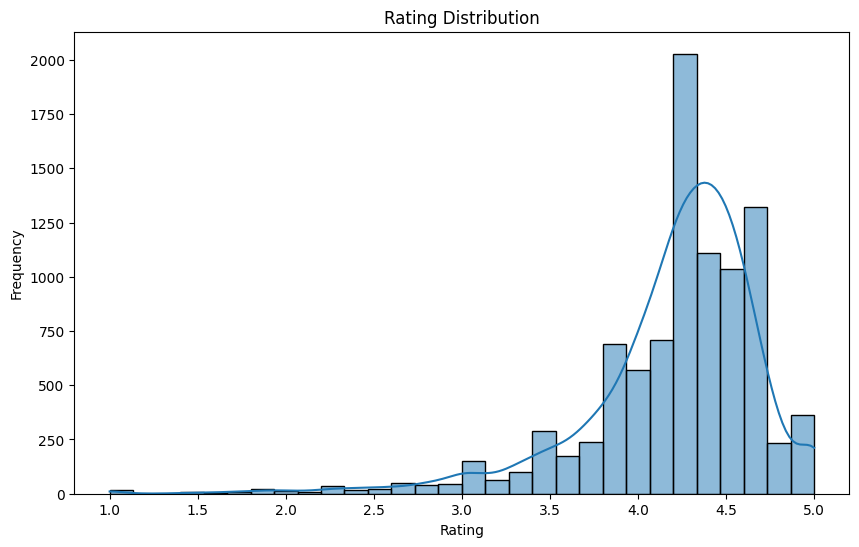

Feature matrix shape: (9366, 12)
Top 10 apps with highest number of reviews:
                                              App       Category  Rating  \
2544                                    Facebook         SOCIAL     4.1   
3943                                    Facebook         SOCIAL     4.1   
336                           WhatsApp Messenger  COMMUNICATION     4.4   
381                           WhatsApp Messenger  COMMUNICATION     4.4   
3904                          WhatsApp Messenger  COMMUNICATION     4.4   
2604                                   Instagram         SOCIAL     4.5   
2611                                   Instagram         SOCIAL     4.5   
2545                                   Instagram         SOCIAL     4.5   
3909                                   Instagram         SOCIAL     4.5   
382   Messenger â€“ Text and Video Chat for Free  COMMUNICATION     4.0   

         Reviews                Size      Installs  Type  Price  \
2544  78158306.0  Varies with

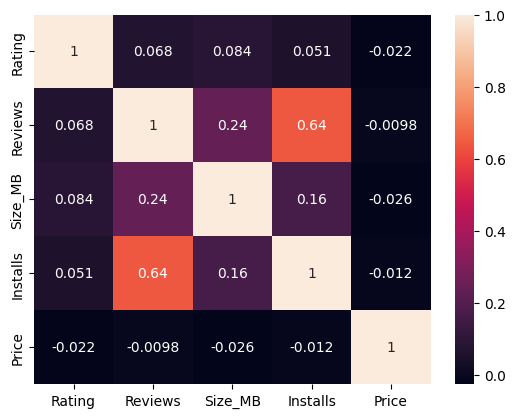

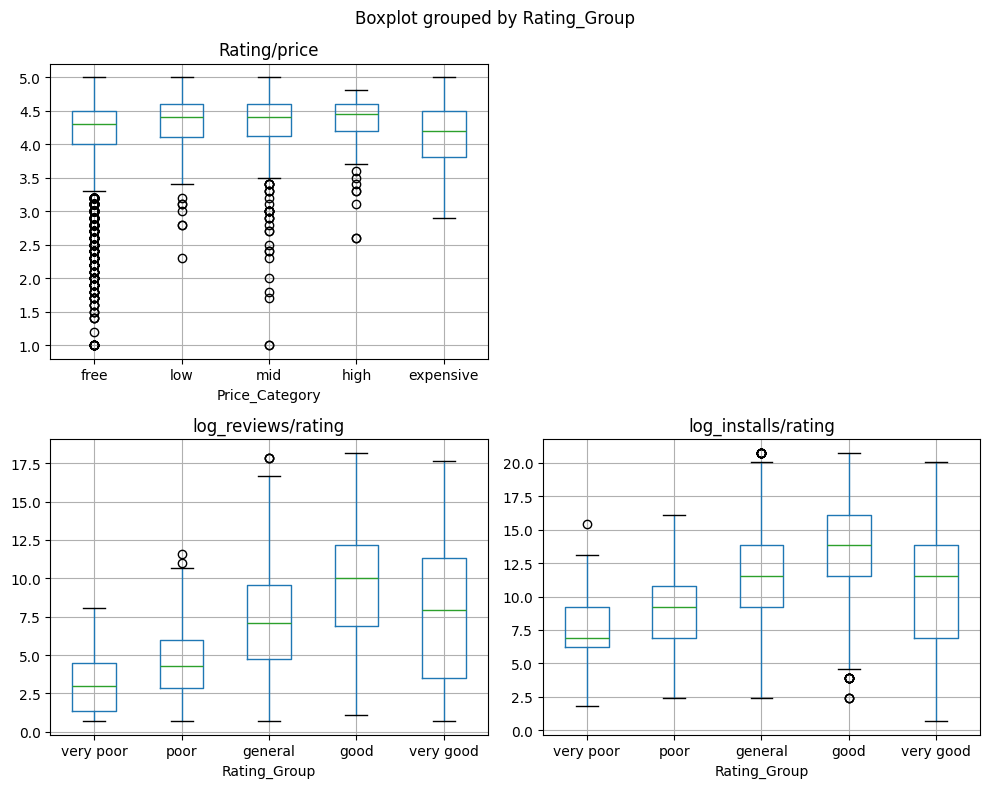

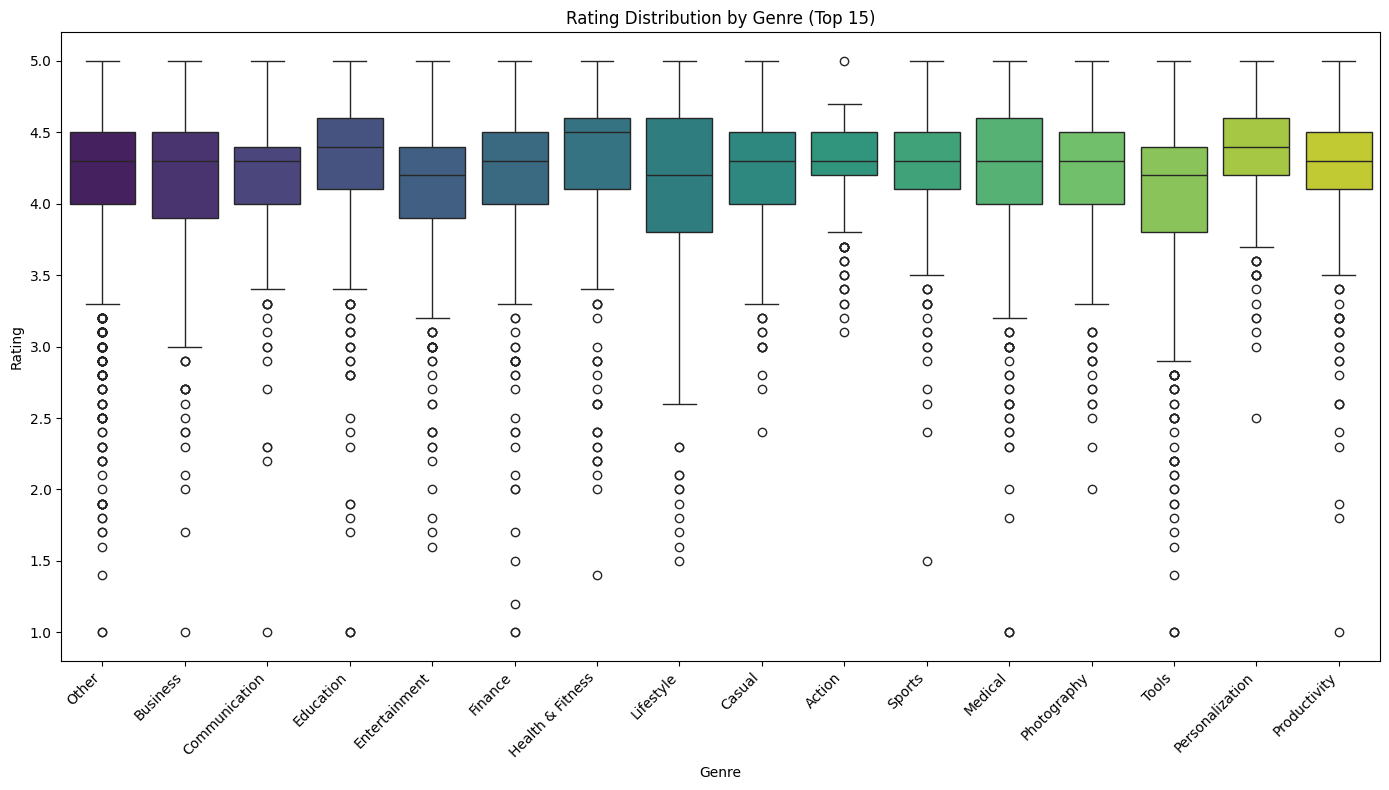

Training set size: (7492, 12), Test set size: (1874, 12)

5-fold cross-validation R² scores: [0.19424072 0.12889121 0.16841801 0.16475586 0.15627819]
Average R²: 0.1625
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 100, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best cross-validation R²: 0.1711

Test set evaluation results:
RMSE: 0.4499
MAE: 0.3092
R²: 0.1790


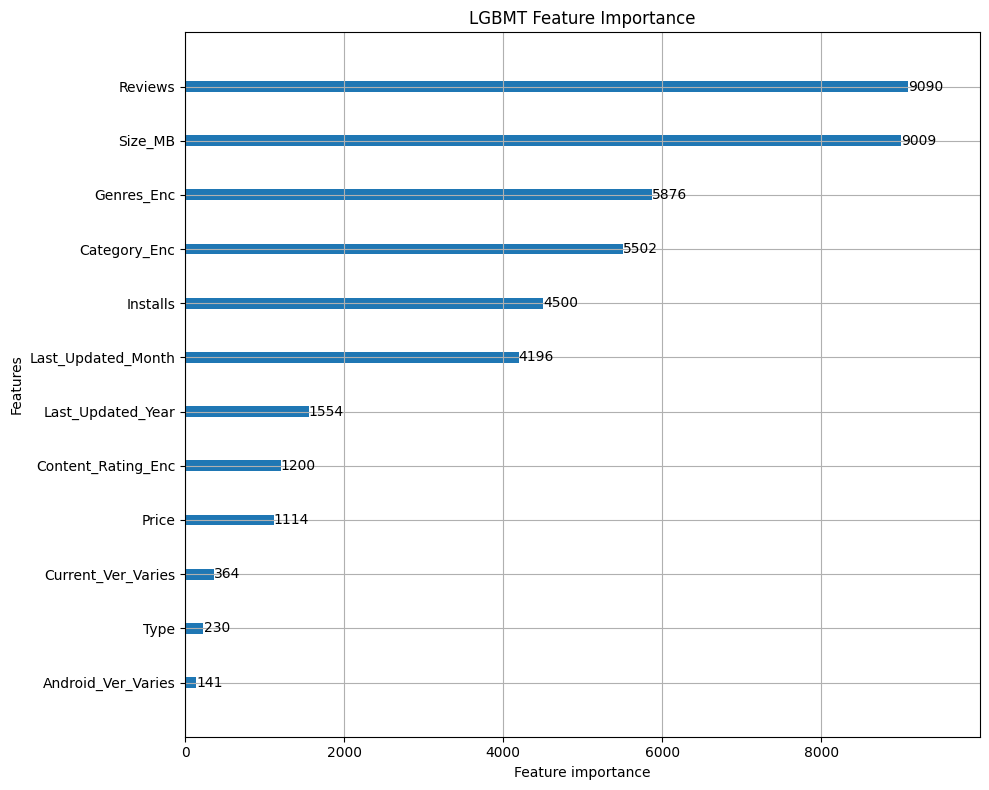


R-squared score of Random Forest using 5-fold cross-validation: [0.20871593 0.14500543 0.17752416 0.15266147 0.12934475]
Random Forest Average R²: 0.1627
Fitting 3 folds for each of 30 candidates, totalling 90 fits

optimal parameters for Random Forest: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Random Forest Best Cross-Validation R²: 0.1806

The evaluation result of the random forest test set:
RMSE: 0.4456
MAE: 0.2952
R²: 0.1946


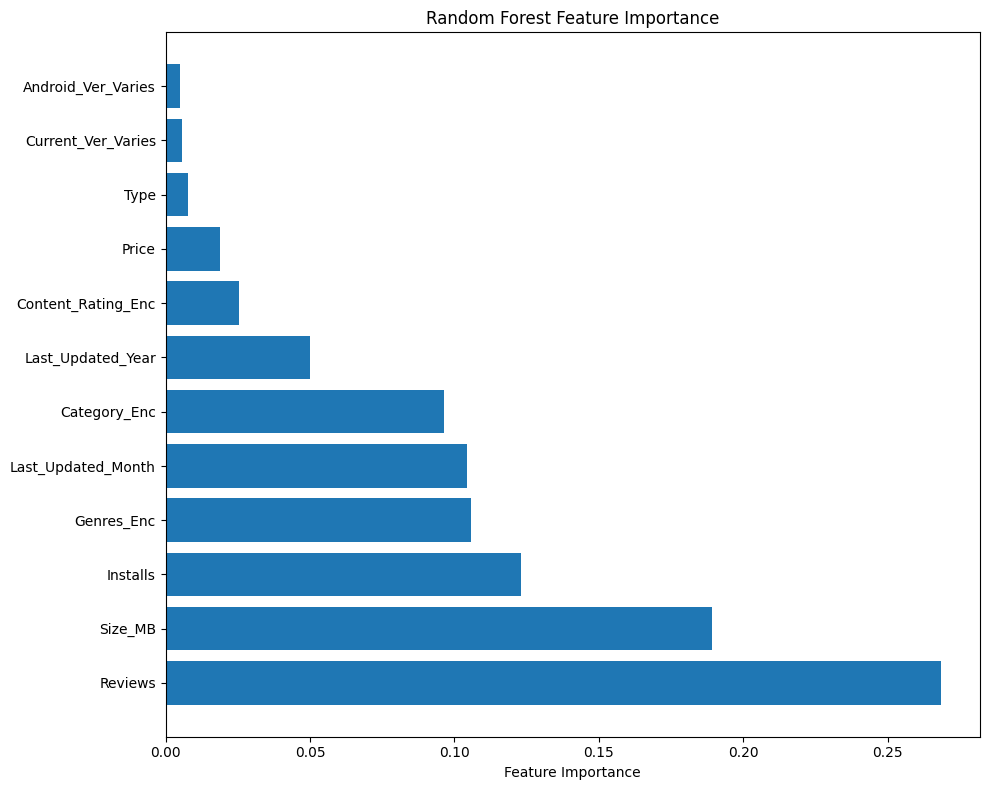

In [ ]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Load data
# ------------------------------
df = pd.read_excel('/content/DSML Individual Coursework Dataset2526 (1).xlsx', sheet_name='Apps')
print("Original data shape:", df.shape)
print("Basic data information:")
print(df.info())

print("Column names:", df.columns.tolist())
print("First 5 rows:\n", df.head())

print("Missing values:\n", df.isnull().sum())
print("\nTarget variable (Rating) distribution:")
print("Descriptive statistics of target variable Rating:\n", df['Rating'].describe())
print(df['Rating'].describe())


# ------------------------------
# 2. Data cleaning and feature engineering
# ------------------------------
# 2.1  Remove rows with missing target variable
df = df.dropna(subset=['Rating']).copy()
# Remove rows with Rating greater than 5
df=df[df['Rating']<= 5]
print("Shape after dropping missing Rating:", df.shape)

# Visualize target variable distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'].dropna(), bins=30, kde=True)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# 2.2 Reviews: convert to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# 2.3 Size: convert to MB numeric, handle "Varies with device"
def convert_size(size_str):
    if pd.isna(size_str):
        return np.nan
    size_str = str(size_str).strip()
    if size_str == 'Varies with device':
        return np.nan
    match = re.match(r'([\d\.]+)\s*([a-zA-Z]*)', size_str)
    if match:
        num = float(match.group(1))
        unit = match.group(2).upper()
        if unit == 'M':
            return num
        elif unit == 'K':
            return num / 1024.0
        else:
            return np.nan
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# 2.4 Installs: remove commas and plus signs, convert to integer
def convert_installs(inst_str):
    if pd.isna(inst_str):
        return np.nan
    inst_str = str(inst_str).replace(',', '').replace('+', '').strip()
    try:
        return int(inst_str)
    except:
        return np.nan

df['Installs'] = df['Installs'].apply(convert_installs)

# 2.5 Price: remove dollar sign, convert to float
def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).replace('$', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return np.nan

df['Price'] = df['Price'].apply(convert_price)

# 2.6 Type: binarize
df['Type'] = df['Type'].map({'Free': 0, 'Paid': 1}).fillna(-1)

# 2.7 Content Rating: label encoding
le_content = LabelEncoder()
df['Content_Rating_Enc'] = le_content.fit_transform(df['Content Rating'].astype(str))

# 2.8 Category: label encoding
le_category = LabelEncoder()
df['Category_Enc'] = le_category.fit_transform(df['Category'].astype(str))

# 2.9 Genres: take first category (if multiple) and encode
df['First_Genre'] = df['Genres'].str.split(';').str[0].fillna('Unknown')
le_genre = LabelEncoder()
df['Genres_Enc'] = le_genre.fit_transform(df['First_Genre'])

# 2.10 Last Updated: extract year and month
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Last_Updated_Year'] = df['Last Updated'].dt.year.fillna(0).astype(int)
df['Last_Updated_Month'] = df['Last Updated'].dt.month.fillna(0).astype(int)

# 2.11 Current Ver & Android Ver: flag for "Varies with device"
df['Current_Ver_Varies'] = (df['Current Ver'] == 'Varies with device').astype(int)
df['Android_Ver_Varies'] = (df['Android Ver'] == 'Varies with device').astype(int)

# 2.12 Select feature columns
feature_cols = [
    'Reviews', 'Size_MB', 'Installs', 'Price', 'Type',
    'Content_Rating_Enc', 'Category_Enc', 'Genres_Enc',
    'Last_Updated_Year', 'Last_Updated_Month',
    'Current_Ver_Varies', 'Android_Ver_Varies'
]
X = df[feature_cols]
y = df['Rating']

# 2.13 Handle missing values in numerical features (median imputation)
num_cols = ['Reviews', 'Size_MB', 'Installs', 'Price']
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# Other features already filled with -1 or encoded, no further processing needed
print("Feature matrix shape:", X.shape)

# ------------------------------------------
# 3. Data analysis after feature engineering
# ------------------------------------------
# 3.1 Correlation heatmap of numerical features. There is some correlation between installs and reviews; generally, apps with high installs also have many reviews.
features_original = ['Rating','Reviews', 'Size_MB', 'Installs', 'Price']
corr_pearson_original = df[features_original].corr(method='pearson')
sns.heatmap(corr_pearson_original, annot=True)

# 3.2 Top 10 apps with highest number of reviews
salesDf=df.sort_values(by='Reviews', ascending=False)
print("Top 10 apps with highest number of reviews:\n", salesDf.head(10))
# Top 10 apps with highest number of installs
salesDf=df.sort_values(by='Installs',ascending=False)
print("Top 10 apps with highest installs:\n", salesDf.head(10))


# 3.3 Which categories have the most apps in the market?
querySer=df.groupby(['Genres']).size()
print("Categories with the most apps in the market:\n", querySer.sort_values(ascending=False))


#3.4 price of  apps influnes
# paid apps situation
fufei=df[features_original].loc[:,'Price']>0
paid=df[features_original].loc[fufei,:]
print("Average price of paid apps:\n", paid.describe())

# Free apps situation
mianfei=df[features_original].loc[:,'Price']<=0
free=df[features_original].loc[mianfei,:]
print("Free apps situation:\n", free.describe())

# What proportion of apps are paid?
querySer=df.groupby(['Type']).size()
print("Proportion of paid apps in total apps:\n", querySer)

#3.5 Boxplot analysis

fig5, axes = plt.subplots(2, 2, figsize=(10, 8))

# Rating boxplot (by price category)
df['Price_Category'] = pd.cut(df['Price'],
                                    bins=[-0.1, 0, 1, 5, 10, float('inf')],
                                    labels=['free', 'low', 'mid', 'high', 'expensive'])

df.boxplot(column='Rating', by='Price_Category', ax=axes[0, 0])
axes[0, 0].set_title('Rating/price')
axes[0, 1].set_visible(False)

# Reviews boxplot (by rating interval)
df['Rating_Group'] = pd.cut(df['Rating'],
                                  bins=[0, 2, 3, 4, 4.5, 5],
                                  labels=['very poor', 'poor', 'general', 'good', 'very good'])

# Take log of Reviews and draw boxplot
df['Log_Reviews'] = np.log1p(df['Reviews'])
log_reviews_by_rating = df[['Log_Reviews', 'Rating_Group']].dropna()
log_reviews_by_rating.boxplot(column='Log_Reviews', by='Rating_Group', ax=axes[1, 0])
axes[1, 0].set_title('log_reviews/rating')

# Installs boxplot (by rating interval)
df['Log_Installs'] = np.log1p(df['Installs'])
log_installs_by_rating = df[['Log_Installs', 'Rating_Group']].dropna()
log_installs_by_rating.boxplot(column='Log_Installs', by='Rating_Group', ax=axes[1, 1])
axes[1, 1].set_title('log_installs/rating')

plt.tight_layout()
plt.show()

# Boxplot of Rating for Genres
# Count the occurrences of each main genre (First_Genre)
genre_counts = df['First_Genre'].value_counts()
# Select the top 15 high-frequency types
top_genres = genre_counts.nlargest(15).index

# Create a new column and label non-high-frequency types as 'Other'
df['Genre_Group'] = df['First_Genre'].apply(lambda x: x if x in top_genres else 'Other')

# Set canvas size
plt.figure(figsize=(14, 8))

# Draw a box plot and group by Genre_Group
sns.boxplot(x='Genre_Group', y='Rating', data=df, palette='viridis')

# Adjust the rotation angle of the label to avoid overlap
plt.xticks(rotation=45, ha='right')
plt.title('Rating Distribution by Genre (Top 15)')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('genre_rating_boxplot.png')  # Optional: Save Image
plt.show()


# ------------------------------
# 4. Split training and test sets
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")


# ------------------------------
# 5. Basic LightGBM model and cross-validation
# ------------------------------
base_model = lgb.LGBMRegressor(objective='regression', random_state=42,verbosity=-1)
cv_scores = cross_val_score(base_model, X_train, y_train, cv=5, scoring='r2')
print("\n5-fold cross-validation R² scores:", cv_scores)
print("Average R²: {:.4f}".format(cv_scores.mean()))

# ------------------------------
# 6. Hyperparameter optimization (random search)
# ------------------------------
param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,          # number of iterations, can be adjusted based on computational power
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest parameters:", random_search.best_params_)
print("Best cross-validation R²: {:.4f}".format(random_search.best_score_))

# ------------------------------
# 7. Final model evaluation
# ------------------------------
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTest set evaluation results:")
print("RMSE: {:.4f}".format(rmse))
print("MAE: {:.4f}".format(mae))
print("R²: {:.4f}".format(r2))

# Optional: feature importance
lgb.plot_importance(best_model, figsize=(10, 8))
plt.title('LGBMT Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


# ------------------------------
# 8. Random Forest Model: Cross-Validation, Hyperparameter Optimization, and Evaluation
# ------------------------------

# 8.1 Basic Random Forest Model with Cross-Validation
base_rf = RandomForestRegressor(random_state=42)
rf_cv_scores = cross_val_score(base_rf, X_train, y_train, cv=5, scoring='r2')
print("\nR-squared score of Random Forest using 5-fold cross-validation:", rf_cv_scores)
print("Random Forest Average R²: {:.4f}".format(rf_cv_scores.mean()))

# 8.2 Hyperparameter Optimization of Random Forest (Random Search)
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=30,                # The number of iterations can be adjusted according to computing power
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("\noptimal parameters for Random Forest:", rf_random_search.best_params_)
print("Random Forest Best Cross-Validation R²: {:.4f}".format(rf_random_search.best_score_))

# 8.3 Final Random Forest Model Evaluation
best_rf = rf_random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nThe evaluation result of the random forest test set:")
print("RMSE: {:.4f}".format(rmse_rf))
print("MAE: {:.4f}".format(mae_rf))
print("R²: {:.4f}".format(r2_rf))

# 8.4 Random Forest Feature Importance Visualization
feature_importance_rf = best_rf.feature_importances_
feature_names = X.columns  # Feature column name

plt.figure(figsize=(10, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.barh(range(len(indices)), feature_importance_rf[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

PHASE 2  K-means

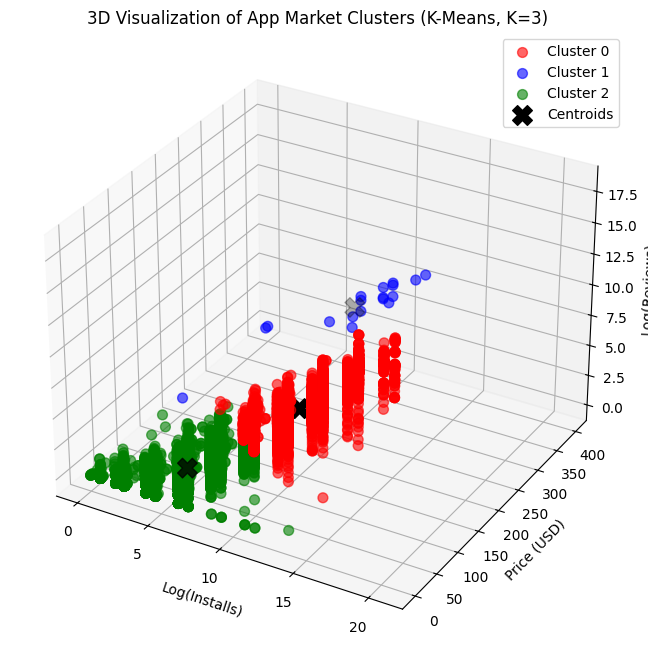

Cluster center point characteristics (Estimate value) :
       Installs       Price       Reviews
0  2.166337e+06    0.129600  42895.035362
1  1.107101e+03  381.380000     91.219908
2  9.831862e+02    0.737808     21.635671


In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Data loading and preprocessing
# Be sure to place the 'DSML Individual Coursework Dataset2526 (1).xlsx' file in the current working directory
file_path = '/content/DSML Individual Coursework Dataset2526 (1).xlsx'
df = pd.read_excel(file_path, sheet_name='Apps')

# Data cleaning: Handle missing values and convert Installs and Reviews into numerical values
# Remove the '+' and ',' characters from "Installs" and convert them to integers.
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Reviews are already in numerical form, but ensure that their type is correct.
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Price: remove dollar sign, convert to float
def convert_price(price_str):
 if pd.isna(price_str):
   return np.nan
 price_str = str(price_str).replace('$', '').replace(',', '').strip()
 try:
   return float(price_str)
 except:
   return np.nan

df['Price'] = df['Price'].apply(convert_price)

# Select the features to be used for clustering and remove the missing values
features = ['Installs', 'Price', 'Reviews']
cluster_data = df[features].dropna().copy()

# 2. Feature Engineering and Standardization
# Perform a log1p transformation on the data to reduce the influence of the long-tailed distribution.
for col in ['Installs', 'Reviews']:
 cluster_data[col] = np.log1p(cluster_data[col])

# Standardize the features so that they are on the same scale.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data)

# 3. Build the K-Means model
# Set the number of clusters. Here, for the sake of demonstration and visualization, we choose K = 3.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

# Add the clustering results back to the data
cluster_data['Cluster'] = cluster_labels

# 4. Result visualization
# Create a 3D scatter plot to display the clustering results
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors and labels
colors = ['red', 'blue', 'green']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
 cluster_subset = cluster_data[cluster_data['Cluster'] == i]
 ax.scatter(cluster_subset['Installs'], cluster_subset['Price'], cluster_subset['Reviews'],
 c=colors[i], label=cluster_names[i], alpha=0.6, s=50)

# Mark the cluster centers
centers_scaled = kmeans.cluster_centers_
# Reverse the center point transformation to the original scale (for display only)
centers_original_scale = scaler.inverse_transform(centers_scaled)
ax.scatter(centers_original_scale[:, 0], centers_original_scale[:, 1], centers_original_scale[:, 2],
c='black', marker='X', s=200, label='Centroids')

ax.set_xlabel('Log(Installs)')
ax.set_ylabel('Price (USD)')
ax.set_zlabel('Log(Reviews)')
ax.set_title('3D Visualization of App Market Clusters (K-Means, K=3)')
ax.legend()
plt.show()

# Output the information (in the original scale) of the cluster center points.
centers_df = pd.DataFrame(centers_original_scale, columns=['Installs', 'Price', 'Reviews'])
centers_df['Installs'] = np.exp(centers_df['Installs']) - 1
centers_df['Reviews'] = np.exp(centers_df['Reviews']) - 1
print("Cluster center point characteristics (Estimate value) :")
print(centers_df)